In [1]:
import pandas as pd

df = pd.read_csv("Food_Nutrition_Dataset.csv")

# Fill the few missing values (iron, vitamin_c) with the median
features = ["calories", "protein", "carbs", "fat", "iron", "vitamin_c"]
df[features] = df[features].fillna(df[features].median())

# The raw "category" has 61 classes for 205 rows -> merge into 5 broad groups
def broad_group(cat):
    c = cat.lower()
    if any(k in c for k in ["juice", "beverage", "drink", "milk", "liquor"]):
        return "Beverages"
    if any(k in c for k in ["cake", "pie", "bread", "bun", "roll", "baked",
                            "sweet", "pudding", "ice cream", "jam", "snack", "chips"]):
        return "Baked goods & sweets"
    if any(k in c for k in ["fruit", "apple", "banana", "berr", "citrus",
                            "grape", "mango", "pear", "strawberr"]):
        return "Fruits"
    if any(k in c for k in ["vegetable", "potato", "onion", "tomato",
                            "coleslaw", "legume", "bean"]):
        return "Vegetables & legumes"
    return "Other"

df["food_group"] = df["category"].apply(broad_group)

X = df[features]
y = df["food_group"]

print(y.value_counts())

food_group
Baked goods & sweets    50
Vegetables & legumes    50
Beverages               45
Other                   31
Fruits                  29
Name: count, dtype: int64


                      precision    recall  f1-score   support

Baked goods & sweets       0.79      0.85      0.81        13
           Beverages       0.64      0.82      0.72        11
              Fruits       0.33      0.14      0.20         7
               Other       0.43      0.38      0.40         8
Vegetables & legumes       0.71      0.77      0.74        13

            accuracy                           0.65        52
           macro avg       0.58      0.59      0.58        52
        weighted avg       0.62      0.65      0.63        52



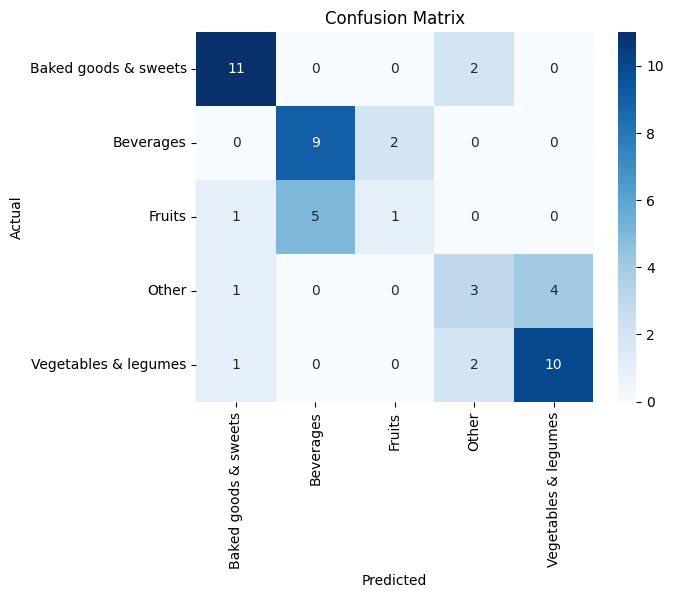

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
preds = rf.predict(X_test_scaled)

print(classification_report(y_test, preds))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, preds, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

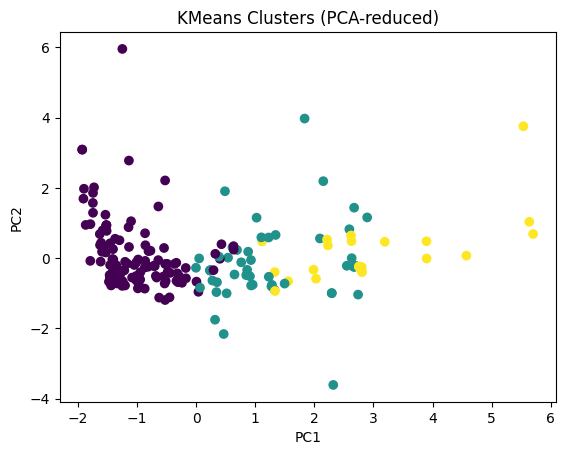

         calories  protein  carbs    fat  iron  vitamin_c
cluster                                                  
0          106.53     1.42  14.35   1.78  0.41      16.67
1          468.58     3.02  48.22  13.73  0.91      10.30
2          494.50    10.19  36.85  12.09  3.03       4.30


In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_scaled_full = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled_full)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis")
plt.title("KMeans Clusters (PCA-reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# What defines each cluster (mean nutrient values)
df["cluster"] = clusters
print(df.groupby("cluster")[features].mean().round(2))